In [1]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:11<00:00, 15.2MB/s]



In [2]:
from zipfile import ZipFile
file_name = "/content/face-mask-dataset.zip"
with ZipFile(file_name,'r') as zip:
  zip.extractall()
  print("dataset extracted.....")

dataset extracted.....


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [4]:
with_mask_files = os.listdir("/content/data/with_mask")
without_mask_files = os.listdir("/content/data/without_mask")

In [5]:
print(len(with_mask_files))
print(len(without_mask_files))

3725
3828


In [6]:
with_mask_labels = [1]*len(with_mask_files)
without_mask_labels = [0]*len(without_mask_files)

In [7]:
type(with_mask_labels)

list

In [8]:
labels = with_mask_labels + without_mask_labels

In [9]:
len(labels)

7553

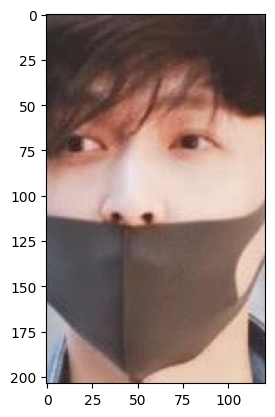

In [10]:
img = mpimg.imread("/content/data/with_mask/with_mask_1001.jpg")
plt.imshow(img)
plt.show()

converting masked images

In [11]:
with_mask_path = "/content/data/with_mask"

data=[]
for image in with_mask_files:
  img = Image.open(os.path.join(with_mask_path,image))
  img = img.resize((128,128))
  img = img.convert("RGB")
  img = np.array(img)
  data.append(img)


without_mask_path = "/content/data/without_mask"

for image in without_mask_files:
  img = Image.open(os.path.join(without_mask_path,image))
  img = img.resize((128,128))
  img = img.convert("RGB")
  img = np.array(img)
  data.append(img)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


converting unmasked images

In [12]:
len(data)

7553

array([[[26, 26, 26],
        [26, 26, 26],
        [26, 26, 26],
        ...,
        [34, 34, 34],
        [35, 35, 35],
        [36, 36, 36]],

       [[26, 26, 26],
        [26, 26, 26],
        [26, 26, 26],
        ...,
        [34, 34, 34],
        [35, 35, 35],
        [36, 36, 36]],

       [[26, 26, 26],
        [26, 26, 26],
        [26, 26, 26],
        ...,
        [34, 34, 34],
        [35, 35, 35],
        [36, 36, 36]],

       ...,

       [[ 1, 14, 30],
        [ 1, 14, 30],
        [ 1, 14, 30],
        ...,
        [ 8,  9, 19],
        [10, 12, 26],
        [11, 16, 34]],

       [[ 1, 14, 29],
        [ 1, 14, 29],
        [ 1, 14, 29],
        ...,
        [ 6,  9, 21],
        [ 8, 12, 26],
        [10, 15, 31]],

       [[ 1, 15, 28],
        [ 1, 15, 28],
        [ 0, 14, 27],
        ...,
        [ 3, 11, 24],
        [ 5, 13, 26],
        [ 7, 15, 28]]], dtype=uint8)
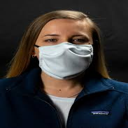

In [13]:
data[1]

In [14]:
type(data)

list

In [15]:
x=np.array(data)
y=np.array(labels)

In [16]:
type(x)

numpy.ndarray

array([[[211, 211, 211],
        [211, 211, 211],
        [212, 212, 212],
        ...,
        [182, 182, 182],
        [181, 181, 181],
        [181, 181, 181]],

       [[211, 211, 211],
        [211, 211, 211],
        [212, 212, 212],
        ...,
        [182, 182, 182],
        [182, 182, 182],
        [181, 181, 181]],

       [[211, 211, 211],
        [211, 211, 211],
        [212, 212, 212],
        ...,
        [183, 183, 183],
        [182, 182, 182],
        [182, 182, 182]],

       ...,

       [[144, 143, 141],
        [143, 142, 140],
        [142, 141, 139],
        ...,
        [ 10,  48, 119],
        [  9,  42, 114],
        [  9,  41, 114]],

       [[142, 141, 139],
        [141, 140, 138],
        [139, 138, 136],
        ...,
        [ 16,  46, 110],
        [ 10,  36,  97],
        [ 17,  44, 103]],

       [[142, 141, 139],
        [141, 140, 138],
        [139, 138, 136],
        ...,
        [ 14,  44, 106],
        [ 23,  48, 107],
        [ 50,  75, 132]]], dtype=uint8)
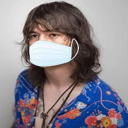

In [17]:
x[0]

In [18]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

scaling

In [19]:
x_train_scaled = x_train/255
x_test_scaled = x_test/255

array([[[203, 203, 203],
        [204, 204, 204],
        [204, 204, 204],
        ...,
        [223, 224, 226],
        [223, 224, 226],
        [223, 224, 226]],

       [[204, 204, 204],
        [204, 204, 204],
        [205, 205, 205],
        ...,
        [224, 225, 227],
        [224, 225, 227],
        [224, 225, 227]],

       [[205, 205, 205],
        [205, 205, 205],
        [205, 205, 205],
        ...,
        [225, 226, 228],
        [225, 226, 228],
        [225, 226, 228]],

       ...,

       [[100,  64,  50],
        [ 98,  62,  48],
        [ 95,  59,  45],
        ...,
        [ 23,  40,  47],
        [ 26,  40,  49],
        [ 31,  42,  54]],

       [[ 98,  63,  49],
        [ 96,  62,  47],
        [ 95,  59,  44],
        ...,
        [ 26,  40,  49],
        [ 26,  39,  50],
        [ 28,  41,  54]],

       [[ 96,  64,  49],
        [ 95,  62,  46],
        [ 94,  60,  42],
        ...,
        [ 28,  40,  52],
        [ 27,  39,  51],
        [ 29,  41,  53]]], dtype=uint8)
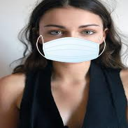

In [20]:
x_train[0]

In [21]:
x_train_scaled[0]

array([[[0.79607843, 0.79607843, 0.79607843],
        [0.8       , 0.8       , 0.8       ],
        [0.8       , 0.8       , 0.8       ],
        ...,
        [0.8745098 , 0.87843137, 0.88627451],
        [0.8745098 , 0.87843137, 0.88627451],
        [0.8745098 , 0.87843137, 0.88627451]],

       [[0.8       , 0.8       , 0.8       ],
        [0.8       , 0.8       , 0.8       ],
        [0.80392157, 0.80392157, 0.80392157],
        ...,
        [0.87843137, 0.88235294, 0.89019608],
        [0.87843137, 0.88235294, 0.89019608],
        [0.87843137, 0.88235294, 0.89019608]],

       [[0.80392157, 0.80392157, 0.80392157],
        [0.80392157, 0.80392157, 0.80392157],
        [0.80392157, 0.80392157, 0.80392157],
        ...,
        [0.88235294, 0.88627451, 0.89411765],
        [0.88235294, 0.88627451, 0.89411765],
        [0.88235294, 0.88627451, 0.89411765]],

       ...,

       [[0.39215686, 0.25098039, 0.19607843],
        [0.38431373, 0.24313725, 0.18823529],
        [0.37254902, 0

In [22]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

In [23]:
num_of_classes = 2
model = Sequential()

model.add(Conv2D(32,3,activation="relu",input_shape=(128,128,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,3,activation="relu"))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(64,activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(32,activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(num_of_classes,activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,708,002 (14.14 MB)

 Trainable params: 3,708,002 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history = model.fit(x_train_scaled,y_train,validation_split=0.1,epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9752 - loss: 0.0721 - val_accuracy: 0.9405 - val_loss: 0.3618
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9755 - loss: 0.0641 - val_accuracy: 0.9306 - val_loss: 0.3826
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9697 - loss: 0.0783 - val_accuracy: 0.9339 - val_loss: 0.3442
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9722 - loss: 0.0628 - val_accuracy: 0.9289 - val_loss: 0.4556
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9744 - loss: 0.0644 - val_accuracy: 0.9372 - val_loss: 0.3613


In [35]:
import pickle

# Save model
with open("face_mask_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [28]:
loss, accuracy = model.evaluate(x_test_scaled,y_test)
print("Test Accuracy:", accuracy, "Test Loss:", loss)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9212 - loss: 0.3198
Test Accuracy: 0.921244204044342 Test Loss: 0.31982019543647766


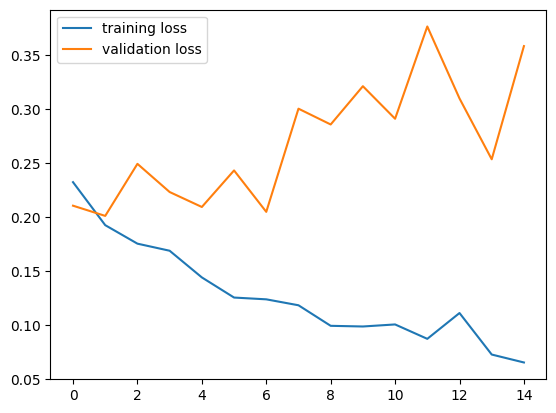

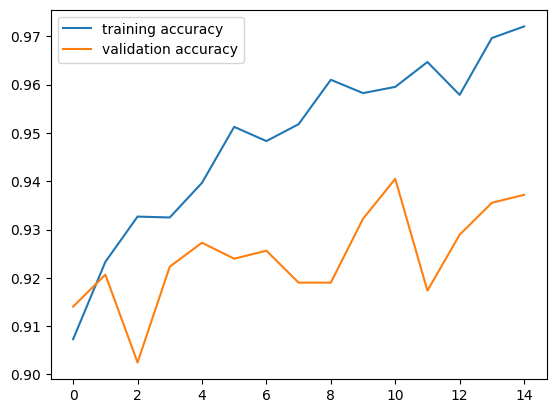

In [32]:
plt.plot(history.history['loss'],label="training loss")
plt.plot(history.history['val_loss'],label="validation loss")
plt.legend()
plt.show()


plt.plot(history.history['accuracy'],label="training accuracy")
plt.plot(history.history['val_accuracy'],label="validation accuracy")
plt.legend()
plt.show()